### PyCaret para Agrupamento

- Documentação 


https://github.com/pycaret/pycaret/blob/master/tutorials/Tutorial%20-%20Clustering.ipynb

### ambiente anaconda

In [1]:
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/pycaret-env/bin/python


In [2]:
import numpy as np
# from pycaret.utils import enable_colab
# enable_colab()

## Base de dados



In [3]:
from pycaret.datasets import get_data

todas_bases = get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


In [4]:


# Dataset	     Data Types	   Default Task	Target Variable 1	Target Variable 2	# Instances	# Attributes	Missing Values
# population	Multivariate	Clustering	    NaN	               NaN	                255	           56	   Y

## Clustering => agrupamento

In [5]:
dataset = get_data('population')


dataset.tail()

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,Arab World,2.741996,2.769515,2.792110,2.811906,2.828133,2.850383,2.867694,2.861356,2.826982,...,2.385159,2.449255,2.469810,2.424469,2.335303,2.242795,2.152384,2.088283,2.050000,2.029991
1,Caribbean small states,1.911755,1.931196,1.893275,1.771980,1.605163,1.448561,1.298573,1.196177,1.164617,...,0.607070,0.633955,0.649817,0.649227,0.636539,0.614597,0.585947,0.557091,0.531885,0.514897
2,Central Europe and the Baltics,0.914136,0.843231,0.893254,0.934352,0.764829,0.735036,0.930801,0.864361,0.735317,...,-0.240341,-0.466785,-0.358132,-0.192448,-0.362710,-0.353692,-0.229155,-0.213202,-0.209757,-0.171544
3,Early-demographic dividend,2.378681,2.399318,2.411945,2.425629,2.435707,2.442855,2.455314,2.457393,2.465558,...,1.596281,1.576339,1.557348,1.538742,1.528734,1.507963,1.476112,1.457399,1.438927,1.419336
4,East Asia & Pacific,0.317912,1.356230,2.403411,2.313426,2.356414,2.604640,2.458242,2.434869,2.665623,...,0.726182,0.687229,0.689983,0.667171,0.658738,0.657531,0.668169,0.670721,0.673393,0.667919


,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
250,Vietnam,1.952436,1.942731,1.954585,1.983669,2.020750,2.067624,2.118327,2.167436,2.219651,...,1.109344,1.083162,1.063214,1.059120,1.049400,1.061610,1.074220,1.064362,1.074207,1.068788
251,Virgin Islands (U.S.),6.356148,6.252036,6.402186,6.502290,6.332713,7.232066,7.138606,7.213753,7.070081,...,-0.151232,-0.257527,-0.309537,-0.359218,-0.413197,-0.455552,-0.482331,-0.512353,-0.542827,-0.573785
252,"Yemen, Rep.",1.638589,1.654696,1.675548,1.701783,1.731891,1.787889,1.847770,1.868445,1.837531,...,2.834859,2.837582,2.824087,2.789801,2.740443,2.688891,2.638109,2.580375,2.515593,2.446705
253,Zambia,3.012355,3.064885,3.105865,3.132456,3.151116,3.163232,3.181647,3.218627,3.278655,...,2.767150,2.843857,2.908179,2.954641,2.987173,3.015603,3.042139,3.060273,3.069640,3.071812
254,Zimbabwe,3.257531,3.289035,3.303133,3.296046,3.277150,3.252359,3.236917,3.242345,3.273772,...,1.099291,1.285552,1.475502,1.657381,1.826380,1.995816,2.150523,2.257867,2.307451,2.313958


list(dataset.columns) # nome do país e a população em cada ano

In [6]:
type(dataset) # tipo dataframe

pandas.core.frame.DataFrame

In [7]:
dataset.shape

(255, 56)

In [8]:
print(f' Países computados {dataset.shape[0]} e a quantidade de anos das populações {dataset.shape[1]}.')

 Países computados 255 e a quantidade de anos das populações 56.


#### base1 , 90% ( no clustering/agrupamento NÃO dividimos como treino e teste)

### encontrar dados similares na parte do agrupamento base1 e base2

In [9]:
base1 = dataset.sample(frac =0.9, random_state=1)
base1.shape

(230, 56)

In [10]:
base1.index

Index([182,  34, 110, 112, 226, 107, 159,  27, 245, 186,
       ...
         7, 250, 141,  86,  96, 222, 227, 215,  68,  50],
      dtype='int64', length=230)

In [11]:
base2 = dataset.drop(base1.index)
base2.shape

(25, 56)

In [12]:
base2.index

Index([ 20,  25,  37,  71,  72,  79, 101, 129, 133, 134, 137, 139, 140, 142,
       144, 146, 156, 157, 178, 192, 203, 204, 212, 235, 237],
      dtype='int64')

## o que tem na base2 não tem na base 1, são dados diferentes

## Configuração do Ambiente PyCaret

#### para normalizar os dados das colunas anuais (normalize=True), colando na escala de 0 a 1.

#### agrupamento faz cálculo de distância. 

##### ignorar a coluna dos países, 'Country Name', pois é distinto cada país é único, o que vale para cada linha ou o país é a evolução anual da população em cada país.  (ignore_features = ['Country Name'])

session_id=1, gera sempre o mesmo valor



In [13]:
from pycaret.clustering import setup

experimento = setup(data=base1, normalize=True, ignore_features = ['Country Name'], session_id=1)

,Description,Value
0,Session id,1
1,Original data shape,"(230, 56)"
2,Transformed data shape,"(230, 55)"
3,Ignore features,1
4,Numeric features,55
5,Rows with missing values,2.2%
6,Preprocess,True
7,Imputation type,simple
8,Numeric imputation,mean
9,Categorical imputation,mode


In [14]:
experimento

In [15]:
# rows with missing values	2.2% (porcentagem de dados faltantes)

# Numeric features	55 => features númericos

In [16]:
# variáveis numéricas

# Numeric Features (55): Indica o número de colunas tratadas como números contínuos ou inteiros.



 ## 33.2) Visualização dos modelos existentes do agrupamento

Todos os algoritmos de agrupamento presentes nesta biblioteca

reference é a documentação na internet

In [17]:
from pycaret.clustering import models
models()

,Name,Reference
ID,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS
birch,Birch Clustering,sklearn.cluster._birch.Birch


### criação do modelo

In [18]:
from pycaret.clustering import create_model
kmeans = create_model('kmeans') # algoritmo clássico

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2850,90.2936,1.1727,0,0,0


In [19]:
# --- MÉTRICAS DE CLUSTERIZAÇÃO ---

# Silhouette: Mede quão próximo um ponto está do seu grupo em relação aos outros. 
# Varia de -1 a 1. Quanto mais perto de 1, melhor definido está o grupo.

# Calinski-Harabasz: Razão entre a dispersão entre grupos e dentro dos grupos. 
# Valores mais altos indicam grupos mais densos e bem separados.

# Davies-Bouldin: Avalia a "similaridade" média entre os clusters. 
# Quanto menor o valor (pererto de 0), melhor é a separação entre os grupos.

# Homogeneity (Homogeneidade): Mede se cada cluster contém apenas membros de 
# uma única classe. Varia de 0 a 1 (1 é o ideal).

# Rand Index (RI): Mede a semelhança entre duas atribuições de grupos. 
# É uma medida de concordância entre o modelo e um gabarito real (se houver).

# Completeness (Completude): Mede se todos os membros de uma classe 
# real foram atribuídos ao mesmo cluster. Complementa a Homogeneidade.

1. Silhouette Score

   Mede a distância média interna ($a$) e a distância média para o cluster mais próximo ($b$).$$S = \frac{b - a}{\max(a, b)}$$

2. Davies-Bouldin Index

Calcula a razão entre as distâncias dentro do cluster ($S_i$) e a distância entre os centroides ($R_{ij}$).$$DB = \frac{1}{n} \sum_{i=1}^{n} \max_{j \neq i} \left( \frac{S_i + S_j}{M_{ij}} \right)$$


3. Rand Index

Baseado na contagem de pares de elementos que estão no mesmo grupo ou em grupos diferentes.$$RI = \frac{a + b}{\binom{n}{2}}$$

In [20]:
kmeans

KMeans(n_clusters=4, random_state=1)

agrupamento já feito com o kmeans

In [21]:
kmeans.get_params() 

# padrão criar n_clusters = 4

# inicialização mais inteligente dos modelos  'init': 'k-means++', dos primeiros centróides do algoritmo

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 4,
 'n_init': 'auto',
 'random_state': 1,
 'tol': 0.0001,
 'verbose': 0}

visualizar os resultados 

In [22]:
# --- K-Means Clustering (Explicação dos Parâmetros) ---

# n_clusters=4: Define que o algoritmo deve encontrar exatamente 4 grupos (clusters). 
# É o parâmetro mais importante, decidido geralmente pelo método do "Cotovelo" (Elbow).

# algorithm='lloyd': Refere-se ao algoritmo clássico do K-Means. 
# Ele calcula a distância entre os pontos e os centros dos grupos repetidamente.

# init='k-means++': Uma técnica inteligente de inicialização. 
# Em vez de escolher centros iniciais totalmente aleatórios, o 'k-means++' 
# os espalha estrategicamente para acelerar a convergência e evitar resultados ruins.

# n_init='auto': Define quantas vezes o algoritmo vai rodar com diferentes 
# sementes iniciais para escolher o melhor resultado final. 'auto' otimiza isso.

# max_iter=300: O limite máximo de vezes que o algoritmo vai tentar ajustar 
# os centros dos grupos em uma única execução.

# tol=0.0001 (Tolerance): Define o critério de parada. Se a mudança na posição 
# dos centros for menor que esse valor, o algoritmo entende que convergiu e para.

# copy_x=True: Mantém os dados originais intactos na memória, 
# fazendo o processamento em uma cópia.

# random_state=1: Garante que os mesmos grupos sejam gerados toda vez que 
# você rodar o código.

A "Mecânica" por trás do K-Means 

O K-Means funciona através da Distância Euclidiana. O objetivo é minimizar a soma dos quadrados dentro dos clusters (Inércia):$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

Onde:$C_i$: É o conjunto de pontos no cluster $i$.

$\mu_i$: É o centroide (média) do cluster $i$.

In [23]:
from pycaret.clustering import assign_model

resultados_kmeans = assign_model(kmeans)
resultados_kmeans 

,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,Cluster
182,1.999441,2.542112,1.986583,2.094972,1.649506,1.791048,1.785233,0.877167,0.894788,1.357592,...,0.932408,0.848701,0.999728,1.111726,0.762480,0.548221,0.768348,1.510339,1.889045,Cluster 1
34,2.116497,2.149796,2.156922,2.214934,2.229381,2.254793,2.273567,2.292557,2.297416,2.303219,...,1.546371,1.505233,1.472448,1.447872,1.424481,1.400239,1.377520,1.357967,1.336820,Cluster 2
110,0.993667,1.110881,1.259962,1.446668,1.650886,1.869693,2.055361,2.152253,2.139257,2.055313,...,2.244585,2.253476,2.260082,2.263388,2.267449,2.268566,2.258908,2.236266,2.204566,Cluster 0
112,1.578436,1.519342,1.473022,1.410306,1.316771,1.143478,0.980880,0.907053,0.935668,-2.795873,...,-1.314207,-1.282069,-1.298720,-1.315808,-1.307543,-1.298720,-1.289322,-1.306163,-1.296264,Cluster 1
226,0.471081,0.551535,0.563634,0.747117,0.941846,0.951566,0.767228,0.561997,0.702746,0.933485,...,0.741553,0.779033,0.851904,0.852525,0.755150,0.739763,0.847349,0.992220,1.054240,Cluster 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,1.466683,1.284566,1.148346,1.074205,1.047669,1.027596,1.003468,0.996884,1.013858,1.043488,...,0.129383,0.106318,0.082410,0.055817,0.022867,-0.006402,-0.006403,0.030180,0.093226,Cluster 1
227,1.978615,2.535012,2.137663,1.654258,1.154842,1.045152,1.239047,1.259256,1.125420,0.722404,...,0.893691,1.270618,1.249485,1.041558,1.111879,1.061819,1.149880,1.220104,1.193620,Cluster 1
215,3.134770,2.798800,2.549616,2.371388,2.251076,2.177580,2.141167,2.133160,2.145700,2.171633,...,1.398923,1.429016,1.459381,1.490032,1.520981,1.552242,1.583826,1.615745,1.648009,Cluster 2
68,1.494501,1.713807,1.874346,2.025475,2.121518,2.199617,2.249999,2.232331,2.079689,1.874218,...,3.400611,3.452935,3.250757,2.880605,2.477952,2.144826,1.900385,1.797364,1.782232,Cluster 0


In [24]:
list(resultados_kmeans.columns)

['1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 'Cluster']

foi criado a coluna 'Cluster' para ver qual grupo cada país pertencia, no agrupamento.

In [25]:
resultados_kmeans['Cluster'].unique() # 4 clusters criados

array(['Cluster 1', 'Cluster 2', 'Cluster 0', 'Cluster 3'], dtype=object)

o pycaret automatizava e concatenava os dados do cluster

In [26]:
resultados_kmeans.tail()

,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,Cluster
222,1.466683,1.284566,1.148346,1.074205,1.047669,1.027596,1.003468,0.996884,1.013858,1.043488,...,0.129383,0.106318,0.082410,0.055817,0.022867,-0.006402,-0.006403,0.030180,0.093226,Cluster 1
227,1.978615,2.535012,2.137663,1.654258,1.154842,1.045152,1.239047,1.259256,1.125420,0.722404,...,0.893691,1.270618,1.249485,1.041558,1.111879,1.061819,1.149880,1.220104,1.193620,Cluster 1
215,3.134770,2.798800,2.549616,2.371388,2.251076,2.177580,2.141167,2.133160,2.145700,2.171633,...,1.398923,1.429016,1.459381,1.490032,1.520981,1.552242,1.583826,1.615745,1.648009,Cluster 2
68,1.494501,1.713807,1.874346,2.025475,2.121518,2.199617,2.249999,2.232331,2.079689,1.874218,...,3.400611,3.452935,3.250757,2.880605,2.477952,2.144826,1.900385,1.797364,1.782232,Cluster 0
50,2.238266,1.416812,0.834202,0.583861,0.578729,0.611793,0.582236,0.577153,0.578949,0.579003,...,0.384068,0.122433,0.072993,0.178314,0.333116,0.447319,0.514335,0.503970,0.432162,Cluster 1


In [27]:
base1.tail()

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
222,St. Vincent and the Grenadines,1.466683,1.284566,1.148346,1.074205,1.047669,1.027597,1.003468,0.996884,1.013858,...,0.146101,0.129383,0.106318,0.082410,0.055817,0.022867,-0.006402,-0.006403,0.030180,0.093226
227,Switzerland,1.978615,2.535013,2.137663,1.654258,1.154843,1.045152,1.239047,1.259256,1.125420,...,0.627558,0.893691,1.270618,1.249485,1.041558,1.111879,1.061819,1.149880,1.220104,1.193620
215,South Africa,3.134770,2.798800,2.549616,2.371388,2.251075,2.177580,2.141167,2.133160,2.145700,...,1.369089,1.398923,1.429016,1.459381,1.490032,1.520981,1.552242,1.583826,1.615745,1.648009
68,British Virgin Islands,1.494501,1.713807,1.874346,2.025475,2.121518,2.199617,2.249999,2.232331,2.079688,...,3.139795,3.400611,3.452934,3.250757,2.880605,2.477952,2.144826,1.900385,1.797364,1.782232
50,Aruba,2.238266,1.416812,0.834202,0.583861,0.578729,0.611793,0.582236,0.577153,0.578949,...,0.795579,0.384068,0.122433,0.072993,0.178314,0.333116,0.447319,0.514335,0.503970,0.432162


In [28]:
# Unindo df1 e df2 pelo index
df_resultados_kmeans = resultados_kmeans.merge(base1[['Country Name']], left_index=True, right_index=True, how='inner')

# how='inner': Mantém apenas os índices que existem nos DOIS dataframes.
# how='left': Mantém todos os índices do df1 e traz os dados do df2 onde houver correspondência.

In [29]:
# verificar em qual local ou grupo o Brasil foi colocado

df_resultados_kmeans[df_resultados_kmeans['Country Name'] == 'Brazil']

,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2008,2009,2010,2011,2012,2013,2014,2015,Cluster,Country Name
67,3.007422,3.033116,3.019752,2.958688,2.86761,2.772251,2.69045,2.620657,2.568056,2.528731,...,1.024472,0.986851,0.967797,0.953765,0.935182,0.913688,0.88636,0.855053,Cluster 2,Brazil


analisar os países que estão no mesmo grupo que o Brasil de crescimento populacional

In [30]:
df_resultados_kmeans[df_resultados_kmeans['Cluster'] == 'Cluster 2']

,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2008,2009,2010,2011,2012,2013,2014,2015,Cluster,Country Name
34,2.116497,2.149796,2.156922,2.214934,2.229381,2.254793,2.273567,2.292557,2.297416,2.303219,...,1.505233,1.472448,1.447872,1.424481,1.400239,1.377520,1.357967,1.336820,Cluster 2,South Asia
186,2.645916,1.925255,1.581209,1.777002,2.321258,2.932295,3.363459,3.603696,3.572378,3.365869,...,-4.180437,-3.671196,-2.595073,-1.169080,0.150167,1.035621,1.239754,0.965239,Cluster 2,Northern Mariana Islands
254,3.257531,3.289035,3.303133,3.296046,3.277150,3.252359,3.236917,3.242345,3.273772,3.319569,...,1.475502,1.657381,1.826380,1.995816,2.150523,2.257867,2.307451,2.313958,Cluster 2,Zimbabwe
4,0.317912,1.356230,2.403411,2.313426,2.356414,2.604640,2.458242,2.434869,2.665623,2.599154,...,0.689983,0.667171,0.658738,0.657531,0.668169,0.670721,0.673393,0.667919,Cluster 2,East Asia & Pacific
228,3.209981,3.212550,3.222638,3.243767,3.271598,3.297007,3.317462,3.338040,3.358633,3.377867,...,3.398176,2.310819,0.744689,-1.064666,-2.581230,-3.339447,-2.888301,-1.449086,Cluster 2,Syrian Arab Republic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,2.345758,2.266838,2.236645,2.269298,2.346685,2.430526,2.505874,2.587989,2.673836,2.759531,...,1.651438,1.699794,1.657974,1.605451,1.574075,1.526576,1.466122,1.397318,Cluster 2,Swaziland
22,2.261280,2.288724,2.295696,2.327474,2.328989,2.336423,2.340790,2.347722,2.349827,2.354239,...,1.574815,1.556479,1.547833,1.528466,1.496718,1.482023,1.471615,1.461425,Cluster 2,Lower middle income
63,2.289003,2.330278,2.383356,2.449330,2.527427,2.594798,2.672722,2.804903,3.000524,3.224101,...,1.964376,1.830649,1.738887,1.652370,1.553600,1.458432,1.364945,1.275736,Cluster 2,Bhutan
250,1.952435,1.942731,1.954585,1.983669,2.020750,2.067624,2.118327,2.167436,2.219651,2.262765,...,1.063214,1.059120,1.049400,1.061610,1.074219,1.064362,1.074207,1.068788,Cluster 2,Vietnam


In [31]:
print(f"""Lista de países no mesmo cluster2 do Brasil: {list(df_resultados_kmeans[df_resultados_kmeans['Cluster'] == 'Cluster 2']['Country Name'].unique())}""")

Lista de países no mesmo cluster2 do Brasil: ['South Asia', 'Northern Mariana Islands', 'Zimbabwe', 'East Asia & Pacific', 'Syrian Arab Republic', 'American Samoa', 'Micronesia, Fed. Sts.', 'Australia', 'Cabo Verde', 'Mexico', 'Tajikistan', 'Indonesia', 'Brazil', 'Central African Republic', 'Egypt, Arab Rep.', 'Upper middle income', 'Panama', 'Uzbekistan', 'Singapore', 'Guam', 'Latin America & the Caribbean (IDA & IBRD countries)', 'Morocco', 'Small states', 'South Asia (IDA & IBRD)', 'Other small states', 'New Caledonia', 'Timor-Leste', 'Tunisia', 'Latin America & Caribbean', 'St. Martin (French part)', 'Virgin Islands (U.S.)', 'World', 'Brunei Darussalam', 'Palau', 'Turkmenistan', 'Seychelles', 'Thailand', 'Djibouti', 'Malaysia', 'Bangladesh', 'Sri Lanka', 'Azerbaijan', 'Nepal', 'Fiji', 'Latin America & Caribbean (excluding high income)', 'East Asia & Pacific (excluding high income)', 'Botswana', 'Venezuela, RB', 'Nicaragua', 'Bahamas, The', 'Ecuador', 'Dominican Republic', 'China', 

## Geração dos gráficos 

gráfico dinâmico


TÉCNICA PCA de redução de dimensionalidade

Principal Component Analysis (PCA) is a popular unsupervised linear transformation technique used for dimensionality reduction by projecting high-dimensional data onto a lower-dimensional space.

In [32]:
from pycaret.clustering import plot_model

plot_model(kmeans)

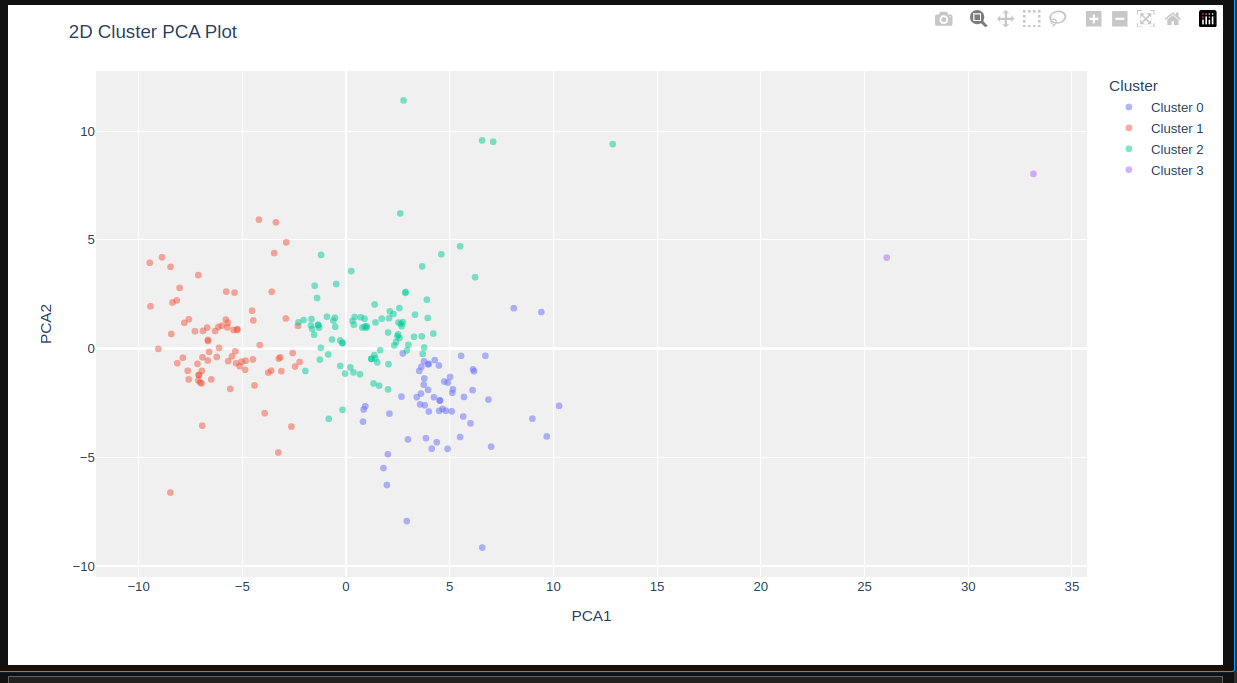

ou seja, 56 ou 57 atributos, ou colunas, foram reduzidos para apenas 2 colunas, PCA 1 e PCA2

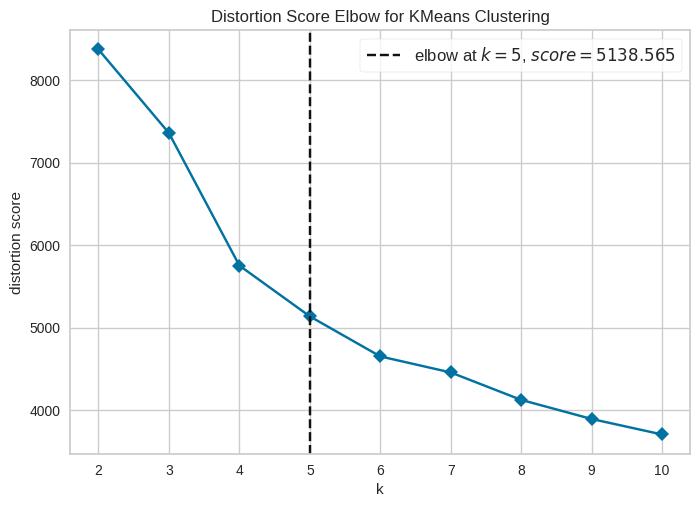

In [33]:
plot_model(kmeans, plot = 'elbow')

método do cotovelo, elbow,

https://blog.cambridgespark.com/how-to-determine-the-optimal-number-of-clusters-for-k-means-clustering-14f27070048f

a linha pontilhada está no eixo x = k = 5, indica o número de cluster ideal para a tabela em dataframe

o valor é onde a caída do eixo y não é tão grande entre cada número de cluster (k), variação mais linear, então pegamos o número do k ideal


onde o eixo y é o valor de distorção

### no sklearn puro temos que colocar na mão o método do cluster ideal

fazendo um for para gerar os registros e fazer o gráfico

https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

#### Gráfico da silhouette 

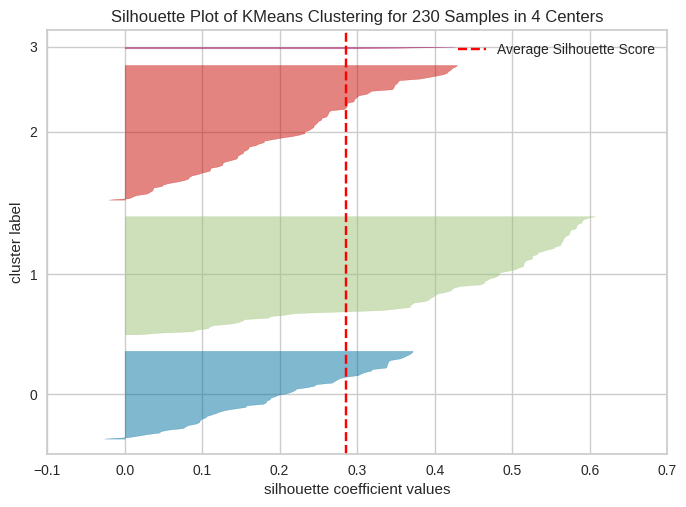

In [34]:
plot_model(kmeans, plot = 'silhouette')

métrica para avaliar os cluster, pelo silhouette

o cluster label 3 e 1 tem pouca densidade (poucos registros no valore de cluster, diminuindo o resultado com menores clusters)

In [35]:
plot_model(kmeans, plot = 'distribution')

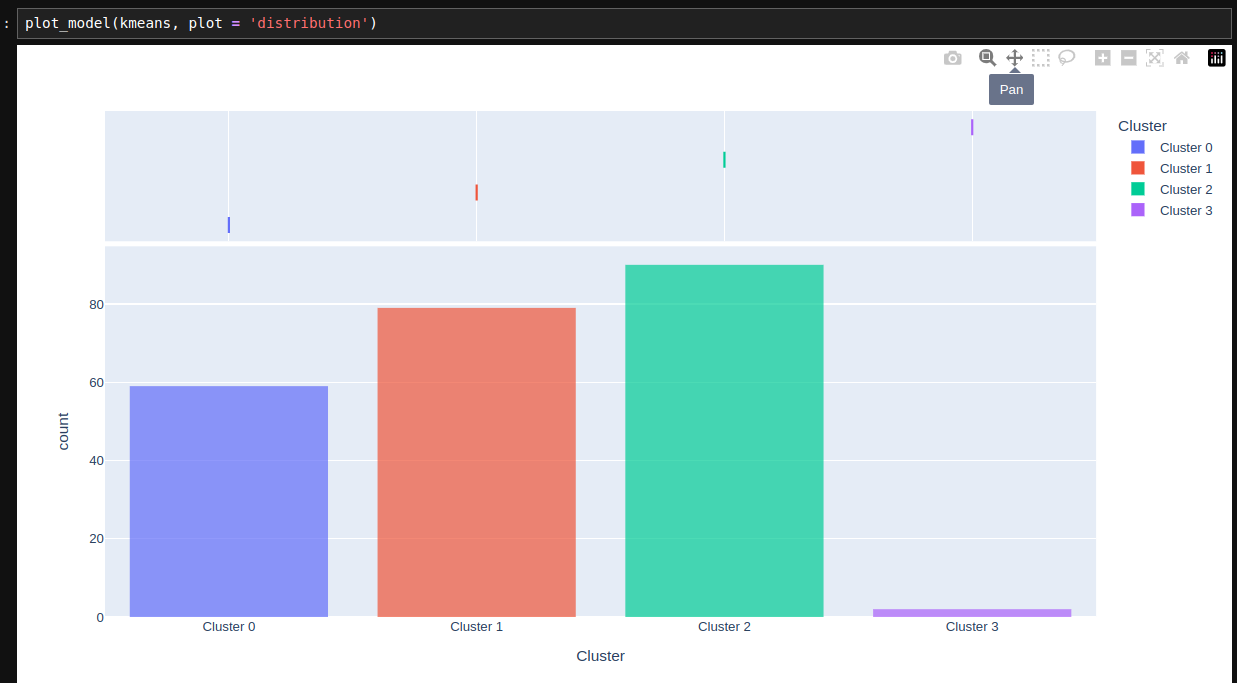

pouquíssimos registros no cluster 3

In [36]:
# agrupando com o valor categórico, coluna  'Country Name'
#plot_model(kmeans, plot = 'distribution', feature = 'Country Name')

In [37]:
import plotly.express as px

# Criando um gráfico de barras que mostra os países e colore por Cluster
fig = px.bar(df_resultados_kmeans, 
             x='Country Name', 
             y='2015',  # Ou qualquer coluna numérica que você queira comparar
             color='Cluster', 
             title='Distribuição de Países por Cluster',
             hover_data=['Country Name'])

fig.show()

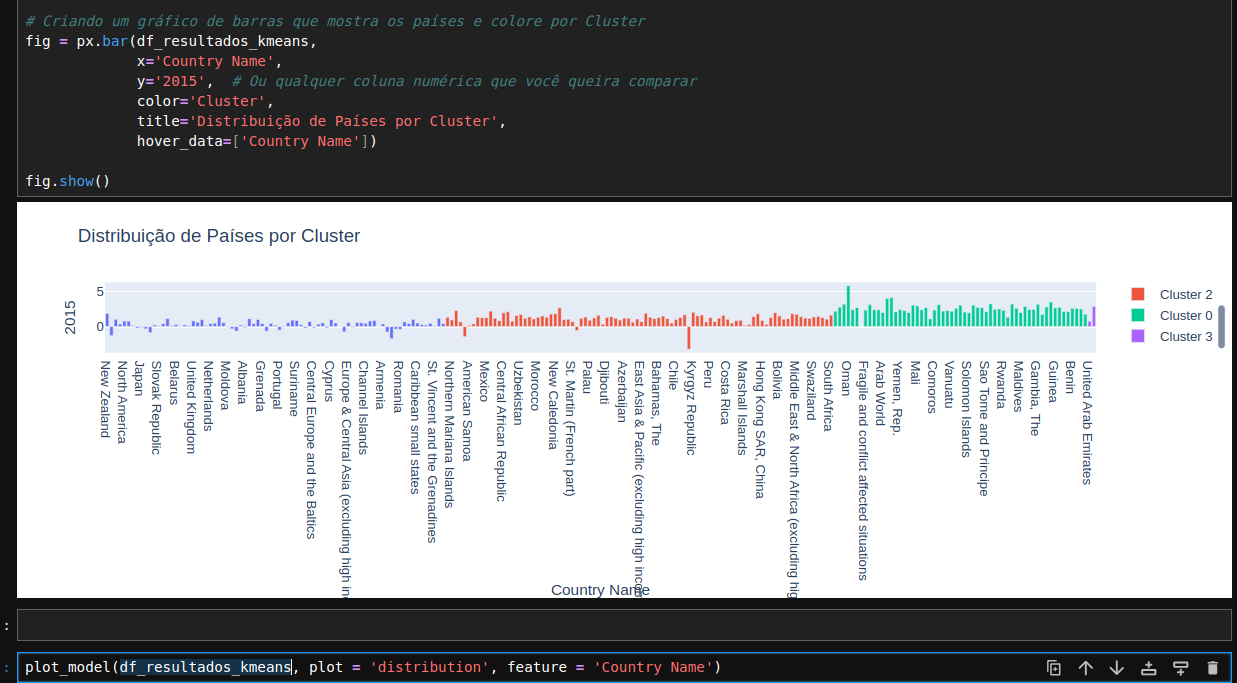

In [38]:
# Para ver o agrupamento espacial (PCA):
plot_model(kmeans, plot = 'cluster')

In [39]:
# --- VISUALIZAÇÃO ALTERNATIVA ---
# Para ver a distribuição de uma variável REAL (ex: ano 2015) entre os clusters:
plot_model(kmeans, plot = 'distribution', feature = '2015') 


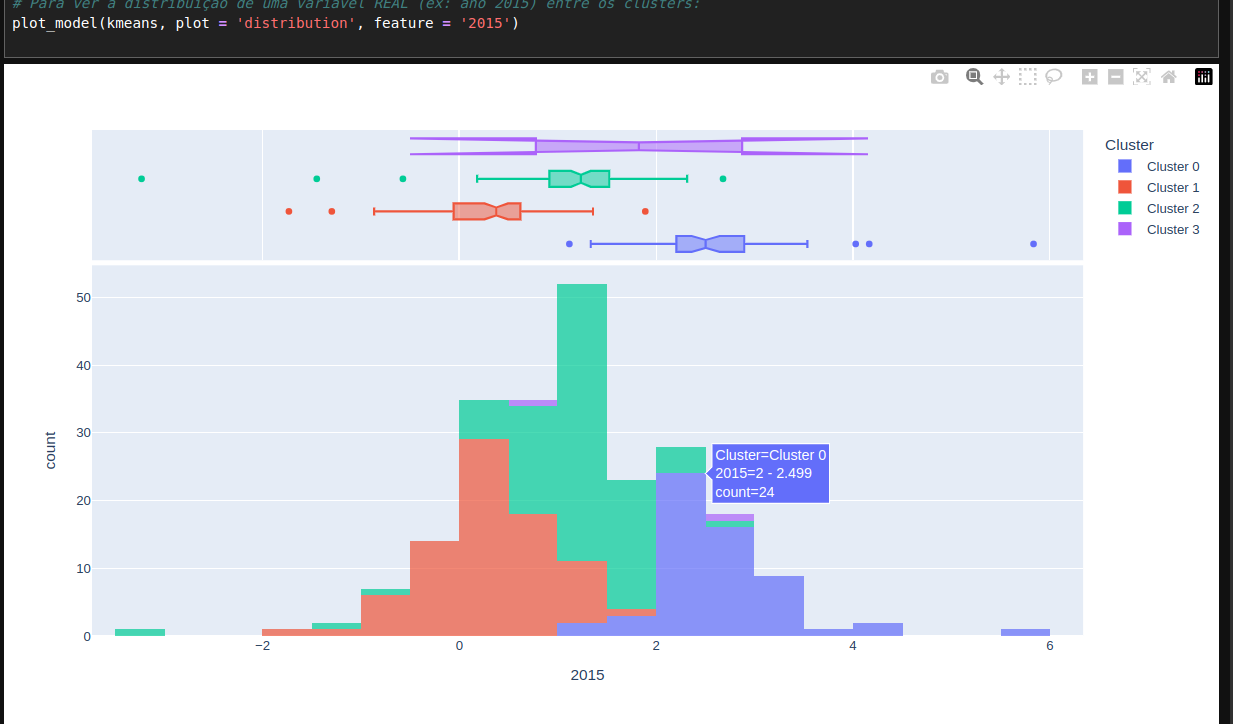

não funciona mais o comando

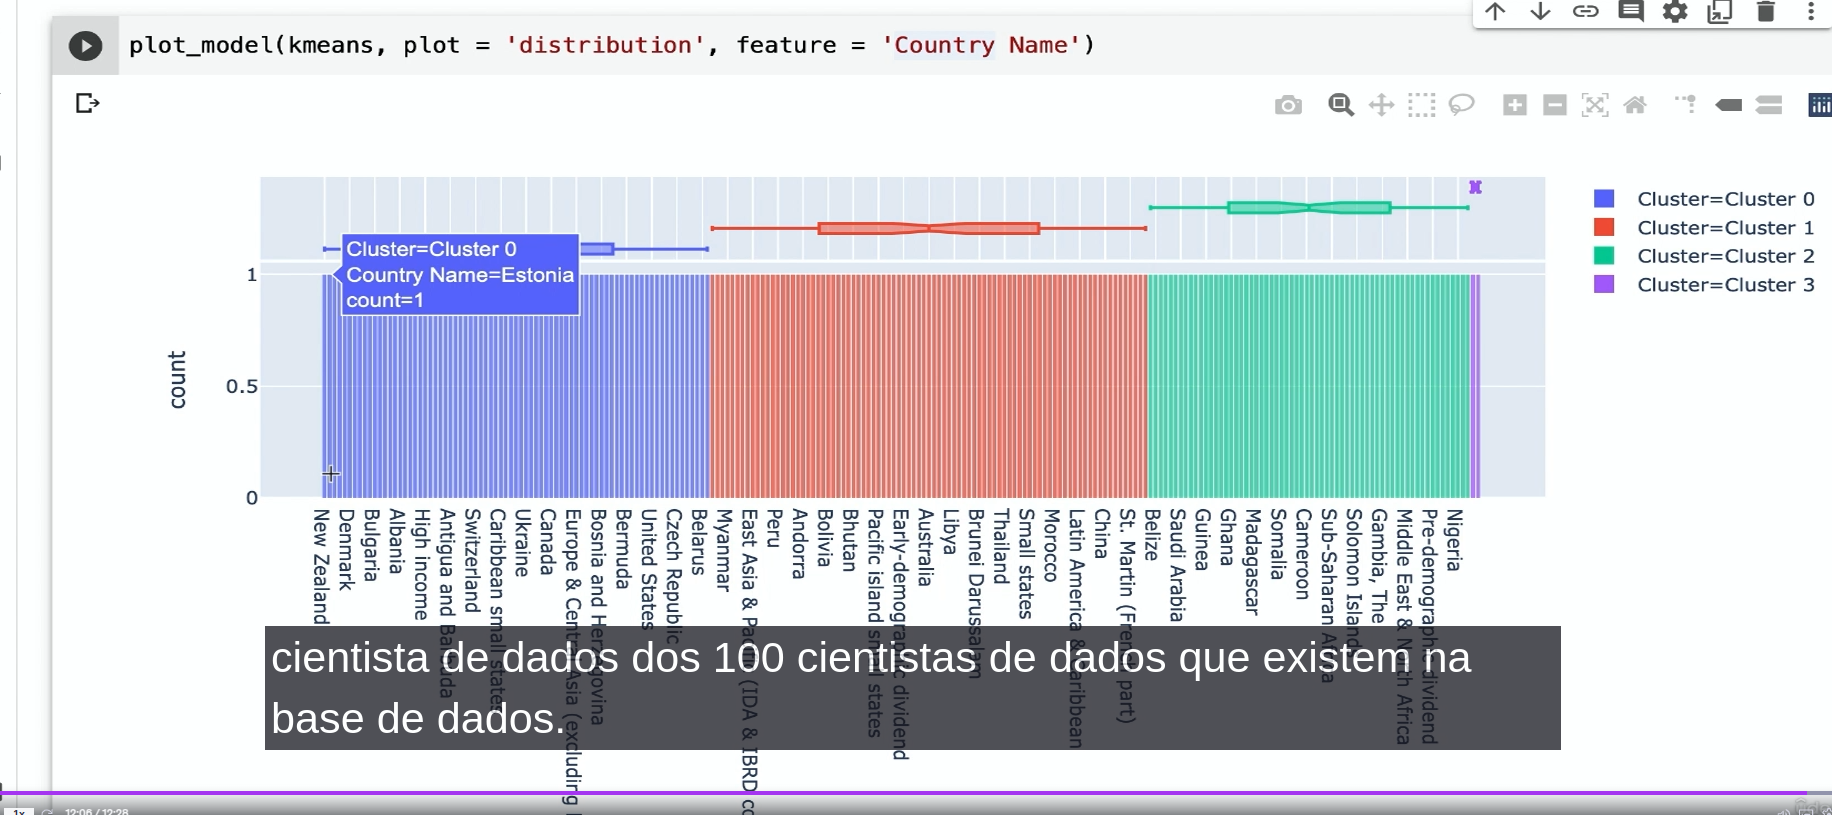

### 33.3) Execução do modelo em dados "não vistos" pelo algoritmo

In [40]:
base2.tail()

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
203,Samoa,3.149296,3.216501,3.210813,3.120648,2.966411,2.808278,2.648136,2.435922,2.170409,...,0.633797,0.641878,0.657411,0.684525,0.716969,0.752421,0.779628,0.785153,0.761315,0.718308
204,San Marino,2.527396,2.563922,2.554005,2.478655,2.361378,2.262065,2.157180,1.950354,1.643493,...,1.108666,1.029584,0.952801,0.894528,0.847504,0.804833,0.753505,0.700097,0.647765,0.586975
212,Slovenia,0.592102,0.595290,0.827299,0.932146,1.038996,1.250067,1.168246,0.884960,0.545751,...,0.319115,0.559208,0.158141,0.903876,0.436079,0.207733,0.210024,0.135726,0.098352,0.086675
235,Trinidad and Tobago,1.969329,1.680252,1.416256,1.191766,1.007559,0.816783,0.651854,0.597401,0.682607,...,0.477526,0.468459,0.465742,0.474177,0.488430,0.502839,0.507330,0.495276,0.461979,0.412957
237,Turkey,2.423854,2.382691,2.348756,2.324105,2.307695,2.290014,2.275853,2.278683,2.301617,...,1.236206,1.173172,1.185293,1.295093,1.461468,1.654851,1.795855,1.819639,1.691319,1.462405


In [41]:
base2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25 entries, 20 to 237
Data columns (total 56 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  25 non-null     object 
 1   1961          25 non-null     float64
 2   1962          25 non-null     float64
 3   1963          25 non-null     float64
 4   1964          25 non-null     float64
 5   1965          25 non-null     float64
 6   1966          25 non-null     float64
 7   1967          25 non-null     float64
 8   1968          25 non-null     float64
 9   1969          25 non-null     float64
 10  1970          25 non-null     float64
 11  1971          25 non-null     float64
 12  1972          25 non-null     float64
 13  1973          25 non-null     float64
 14  1974          25 non-null     float64
 15  1975          25 non-null     float64
 16  1976          25 non-null     float64
 17  1977          25 non-null     float64
 18  1978          25 non-null     float

In [42]:
base2.dtypes


Country Name     object
1961            float64
1962            float64
1963            float64
1964            float64
1965            float64
1966            float64
1967            float64
1968            float64
1969            float64
1970            float64
1971            float64
1972            float64
1973            float64
1974            float64
1975            float64
1976            float64
1977            float64
1978            float64
1979            float64
1980            float64
1981            float64
1982            float64
1983            float64
1984            float64
1985            float64
1986            float64
1987            float64
1988            float64
1989            float64
1990            float64
1991            float64
1992            float64
1993            float64
1994            float64
1995            float64
1996            float64
1997            float64
1998            float64
1999            float64
2000            float64
2001            

In [43]:
#base2 = base2.astype("float32")


In [44]:
df_nao_visto = base2.copy()

In [45]:
from pycaret.clustering import *


### adaptando a nova versão, pois não funciona na versão atual o predict_model

#kmeans_predictions = predict_model(model = kmeans, data = base2)


In [46]:
import pycaret
print(pycaret.__version__)

3.3.2


Models that do not support ‘predict’ method cannot be used in the predict_model.

The behavior of the predict_model is changed in version 2.1 without backward compatibility. As such, the pipelines trained using the version (<= 2.0), may not work for inference with version >= 2.1. You can either retrain your models with a newer version or downgrade the version for inference.

https://pycaret.readthedocs.io/en/stable/api/clustering.html

In [47]:
## só funciona no pip install pycaret==2.3.10
# pip install pycaret==2.0

#kmeans_predictions = predict_model(model = kmeans, data = unseen_data)


In [48]:
num_cols = list(df_nao_visto.select_dtypes(include=[np.number]).columns)
num_cols

['1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015']

In [49]:
num_cols = list(
    base1.drop(columns=['Country Name'])
         .select_dtypes(include=[np.number])
         .columns
)

s = setup(
    data=base1.drop(columns=['Country Name']),
    session_id=42,
    normalize=True,
    numeric_features=num_cols,
    verbose=False
)


In [50]:
# 2️⃣ treina
kmeans = create_model('kmeans')


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2812,83.3296,1.2835,0,0,0


## oficial teste no sklearn

In [53]:
from sklearn.preprocessing import StandardScaler

cols = base2.drop(columns=['Country Name']).columns

scaler = StandardScaler()

X_train = scaler.fit_transform(base2[cols])
X_train = X_train.astype("float64")


In [54]:
base2.isna().sum().sort_values(ascending=False).head(10)
# problema nos dados faltantes

1992            1
1993            1
1994            1
1995            1
Country Name    0
1961            0
1990            0
1991            0
1996            0
1997            0
dtype: int64

In [55]:
# arrumar antes de normalizar
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cols = base2.drop(columns=['Country Name']).columns

# Imputação
imputer = SimpleImputer(strategy="median")
X_imputado = imputer.fit_transform(base2[cols])

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_imputado).astype("float64")


In [56]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 4,   
  random_state = 1,     #random_state=42,
    # n_init=10
  algorithm ='lloyd',
  copy_x = True,
  init = 'k-means++',
  max_iter = 300,  
  n_init = 'auto',
  tol = 0.0001,
  verbose = 0    
)

kmeans.fit(X_train)


KMeans(n_clusters=4, random_state=1)

In [57]:
# {'algorithm': 'lloyd',
#  'copy_x': True,
#  'init': 'k-means++',
#  'max_iter': 300,
#  'n_clusters': 4,
#  'n_init': 'auto',
#  'random_state': 1,
#  'tol': 0.0001,
#  'verbose': 0}


In [58]:
kmeans.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 4,
 'n_init': 'auto',
 'random_state': 1,
 'tol': 0.0001,
 'verbose': 0}

In [62]:
X_novo = df_nao_visto[cols]

X_novo_imp = imputer.transform(X_novo)
X_novo_norm = scaler.transform(X_novo_imp).astype("float64")

clusters = kmeans.predict(X_novo_norm)

base2_cluster = df_nao_visto.copy()
base2_cluster["Cluster"] = clusters


In [63]:
base2_cluster

,Country Name,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,Cluster
20,Low & middle income,1.303926,1.860753,2.338774,2.311674,2.328088,2.424018,2.367054,2.379383,2.416060,...,1.321013,1.318521,1.322586,1.321704,1.323835,1.322282,1.321783,1.316720,1.303585,1
25,Middle East & North Africa (IDA & IBRD countries),2.661590,2.669360,2.678723,2.693598,2.709831,2.730300,2.741881,2.728886,2.686437,...,1.782840,1.799052,1.802216,1.792764,1.787035,1.770190,1.763456,1.758094,1.753158,1
37,Sub-Saharan Africa (excluding high income),2.405521,2.414234,2.428269,2.446306,2.467617,2.492378,2.519372,2.546593,2.573163,...,2.756686,2.769071,2.774611,2.774653,2.772228,2.768171,2.759708,2.747007,2.730999,2
71,Burkina Faso,1.342840,1.334320,1.351483,1.403717,1.479076,1.562532,1.635169,1.689184,1.717433,...,3.059559,3.072128,3.058629,3.027773,2.992039,2.960440,2.932567,2.911018,2.893466,2
72,Burundi,1.906363,1.887975,1.929539,2.047881,2.202588,2.401721,2.543444,2.508815,2.254373,...,3.544436,3.544561,3.519276,3.477233,3.418643,3.358846,3.316265,3.297804,3.292392,2
79,Chad,1.940259,1.970832,1.979348,1.959559,1.924917,1.874306,1.840461,1.861116,1.951818,...,3.357255,3.287234,3.274381,3.297145,3.324413,3.334069,3.328243,3.301595,3.261297,2
101,Equatorial Guinea,1.177029,1.107137,1.175509,1.427745,1.753794,2.218125,2.500511,2.190771,1.141020,...,3.062345,3.021633,3.004723,3.002597,3.002061,2.992523,2.973588,2.942547,2.902460,2
129,India,1.988187,2.020621,2.046165,2.063456,2.075977,2.083430,2.094185,2.117912,2.158447,...,1.502934,1.462901,1.419375,1.374351,1.328401,1.285832,1.251191,1.226730,1.209295,1
133,Ireland,-0.148594,0.411629,0.583615,0.486083,0.374314,0.398884,0.471402,0.450327,0.584797,...,2.890960,2.038708,1.015663,0.544884,0.364214,0.220501,0.248160,0.410851,0.507199,0
134,Isle of Man,-0.181830,0.468366,1.042305,1.474139,1.780592,2.074443,2.327085,2.412406,2.303389,...,0.986366,0.999699,0.975441,0.928078,0.876059,0.831153,0.793079,0.766181,0.746686,0


plotagem 

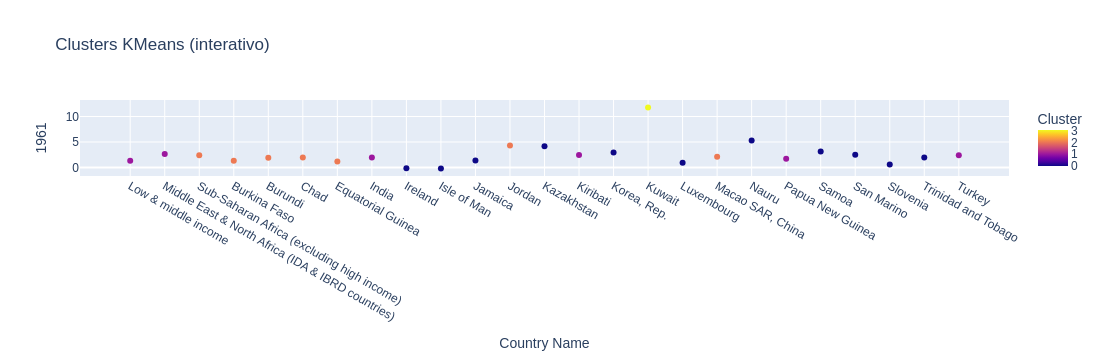

In [65]:
import plotly.express as px

fig = px.scatter(
    base2_cluster,
    x=base2_cluster.columns[0],
    y=base2_cluster.columns[1],
    color="Cluster",
    title="Clusters KMeans (interativo)",
    hover_data=base2_cluster.columns
)

fig.show()


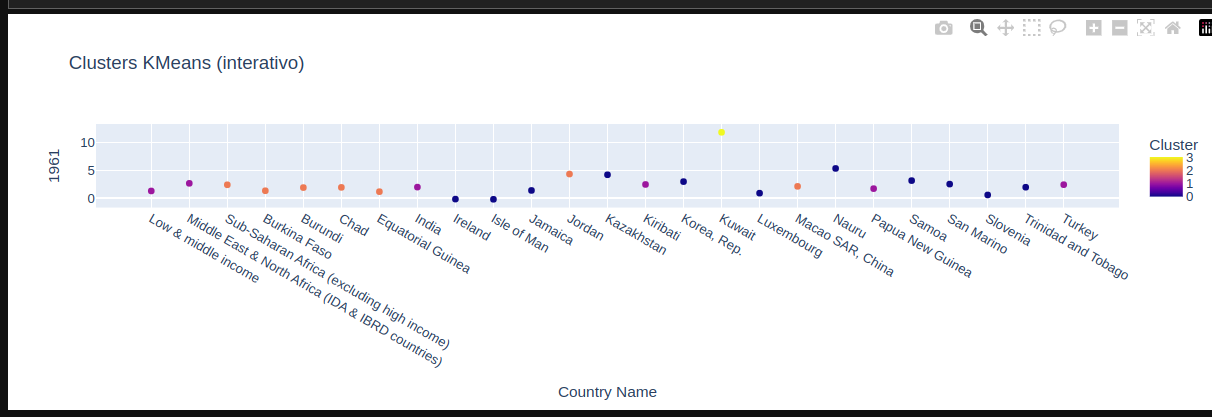

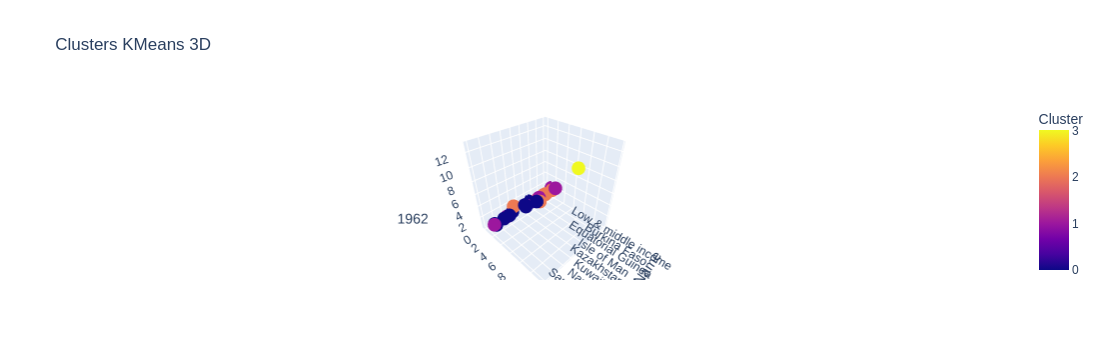

In [66]:
fig = px.scatter_3d(
    base2_cluster,
    x=base2_cluster.columns[0],
    y=base2_cluster.columns[1],
    z=base2_cluster.columns[2],
    color="Cluster",
    title="Clusters KMeans 3D",
    hover_data=base2_cluster.columns
)

fig.show()


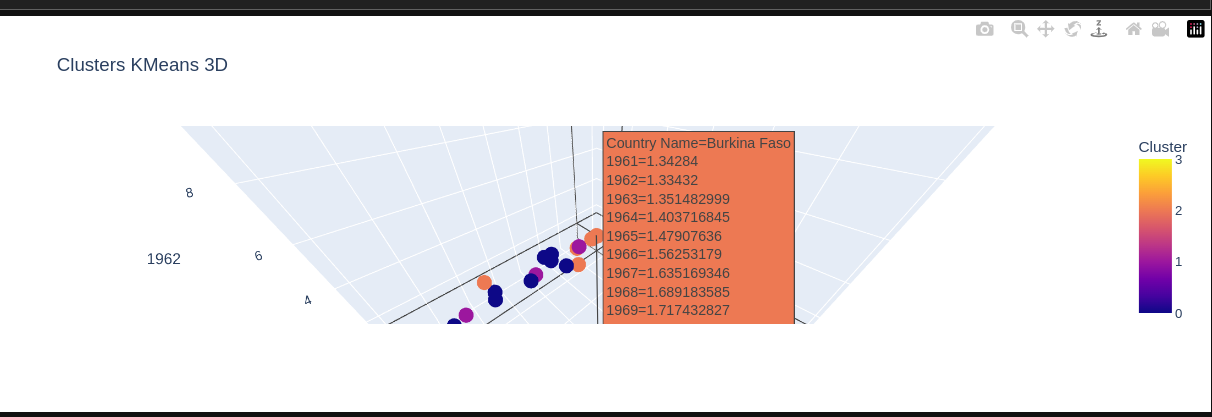

### Adaptado como PCA

In [69]:
from sklearn.cluster import KMeans
# kmeans = KMeans(n_clusters = 4,   
#   random_state = 1,     #random_state=42,
#     # n_init=10
#   algorithm ='lloyd',
#   copy_x = True,
#   init = 'k-means++',
#   max_iter = 300,  
#   n_init = 'auto',
#   tol = 0.0001,
#   verbose = 0    
# )

# kmeans.fit(X_train)
clusters = kmeans.fit_predict(X_train)

In [70]:
base2_cluster = base2.copy()
base2_cluster["cluster"] = clusters

In [72]:
from sklearn.decomposition import PCA
import pandas as pd
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = clusters


In [73]:
df_pca

,PC1,PC2,Cluster
0,-0.776157,-0.476316,1
1,2.176226,-0.310270,1
2,4.618985,0.869894,2
3,3.699846,2.566612,2
4,4.411332,2.001088,2
5,5.930090,3.115630,2
6,5.048102,11.883666,2
7,-0.056044,-0.094557,1
8,-5.090165,-0.162998,0
9,-4.442925,-0.984647,0


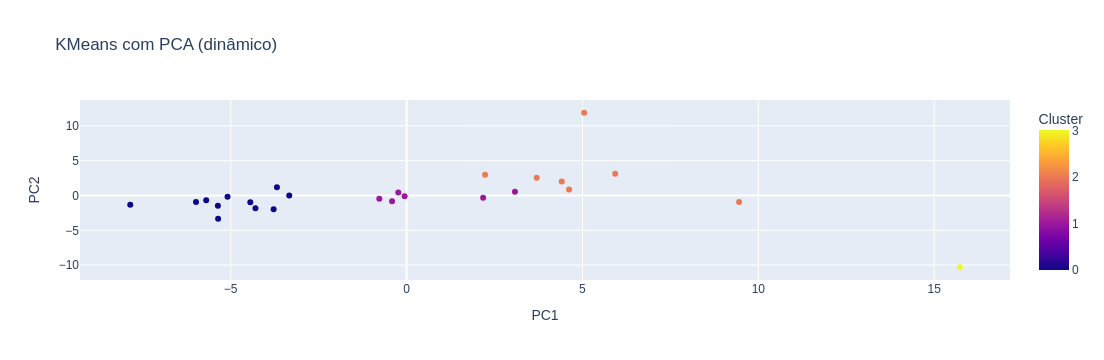

In [75]:
fig = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    color="Cluster",
    title="KMeans com PCA (dinâmico)"
)

fig.show()


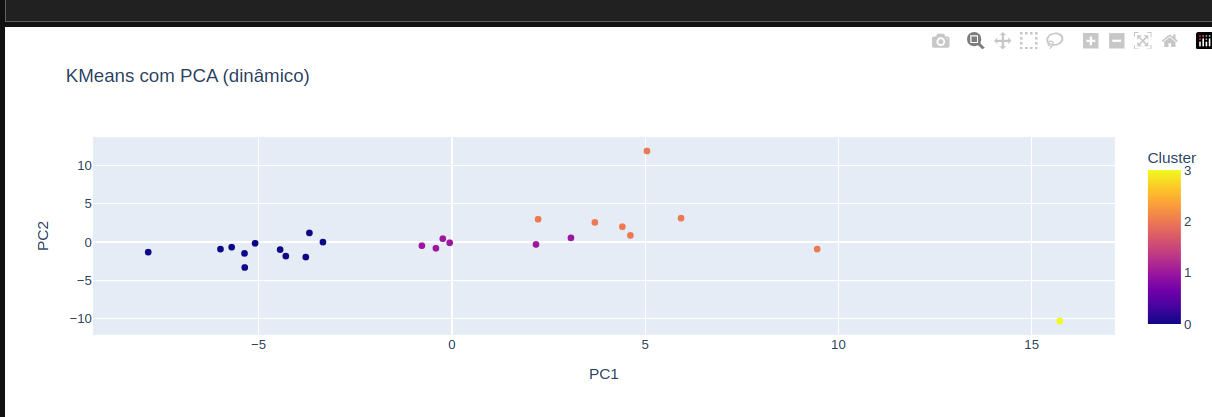

## fazendo o último teste

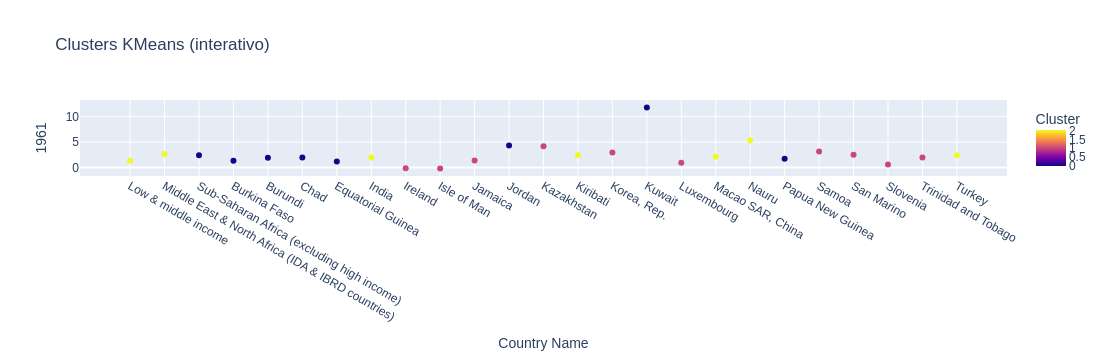

In [76]:


## refazendo 

# arrumar antes de normalizar
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cols = base1.drop(columns=['Country Name']).columns

# Imputação
imputer = SimpleImputer(strategy="median")
X_imputado = imputer.fit_transform(base1[cols])

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_imputado).astype("float64")



# arrumar antes de normalizar
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cols = base2.drop(columns=['Country Name']).columns

# Imputação
imputer = SimpleImputer(strategy="median")
X_imputado = imputer.fit_transform(base2[cols])

# Normalização
scaler = StandardScaler()
X_verifica = scaler.fit_transform(X_imputado).astype("float64")


from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 4,   
  random_state = 1,     #random_state=42,
    # n_init=10
  algorithm ='lloyd',
  copy_x = True,
  init = 'k-means++',
  max_iter = 300,  
  n_init = 'auto',
  tol = 0.0001,
  verbose = 0    
)

kmeans.fit(X_train)


# ajuste do treino
X_novo = df_nao_visto[cols]
X_novo_imp = imputer.transform(X_novo)
X_novo_norm = scaler.transform(X_novo_imp).astype("float64")
clusters = kmeans.predict(X_novo_norm)
base2_cluster = df_nao_visto.copy()
base2_cluster["Cluster"] = clusters


import plotly.express as px

fig = px.scatter(
    base2_cluster,
    x=base2_cluster.columns[0],
    y=base2_cluster.columns[1],
    color="Cluster",
    title="Clusters KMeans (interativo)",
    hover_data=base2_cluster.columns
)

fig.show()




## salvando o modelo

In [88]:
from pycaret.clustering import save_model
save_model(kmeans,'kmeans_final_agrupamento')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['1961', '1962', '1963', '1964',
                                              '1965', '1966', '1967', '1968',
                                              '1969', '1970', '1971', '1972',
                                              '1973', '1974', '1975', '1976',
                                              '1977', '1978', '1979', '1980',
                                              '1981', '1982', '1983', '1984',
                                              '1985', '1986', '1987', '1988',
                                              '1989', '1990', ...],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('normalize', TransformerWrapper(transfo

In [89]:


# carregar o modelo 

from pycaret.clustering import load_model
kmeans_carregado = load_model('kmeans_final_agrupamento')

Transformation Pipeline and Model Successfully Loaded


In [90]:
kmeans_carregado

Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['1961', '1962', '1963', '1964',
                                             '1965', '1966', '1967', '1968',
                                             '1969', '1970', '1971', '1972',
                                             '1973', '1974', '1975', '1976',
                                             '1977', '1978', '1979', '1980',
                                             '1981', '1982', '1983', '1984',
                                             '1985', '1986', '1987', '1988',
                                             '1989', '1990', ...],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('normalize', TransformerWrapper(transformer=StandardScaler())),
                ('trained_model', KMeans(n_clusters=4, random_state=1))])

In [92]:
# previsoes = predict_model(kmeans_carregado, data = base2)

# previsoes
